In [31]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    precision_recall_fscore_support,
    classification_report,
    pairwise_distances
)
from sklearn.metrics import pairwise_distances

np.random.seed(42)
torch.manual_seed(42)

In [32]:
X_train = np.load('preprocessing/X_train.npy')
X_val = np.load('preprocessing/X_val.npy')
X_test = np.load('preprocessing/X_test.npy')
y_train = np.load('preprocessing/y_train.npy')
y_val = np.load('preprocessing/y_val.npy')
y_test = np.load('preprocessing/y_test.npy')

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (2099, 13), Val: (450, 13), Test: (451, 13)


In [33]:
class RBFLayer(nn.Module):
    """
    لایه توابع پایه شعاعی (RBF)
    φ(x) = exp(-||x-c||² / (2σ²))
    """

    def __init__(self, num_inputs, num_centers, centers=None, sigma=1.0,
                 trainable_centers=False, trainable_sigma=False):
        super().__init__()
        self.num_centers = num_centers
        self.num_inputs = num_inputs

        if centers is None:
            centers = np.random.randn(num_centers, num_inputs) * 0.1

        self.centers = nn.Parameter(
            torch.tensor(centers, dtype=torch.float32),
            requires_grad=trainable_centers
        )

        if isinstance(sigma, (float, int)):
            sigma = np.full((num_centers,), sigma)

        self.sigma = nn.Parameter(
            torch.tensor(sigma, dtype=torch.float32),
            requires_grad=trainable_sigma
        )

    def forward(self, x):
        diff = x.unsqueeze(1) - self.centers.unsqueeze(0)
        distances_sq = torch.sum(diff ** 2, dim=2)
        out = torch.exp(-distances_sq / (2 * self.sigma.unsqueeze(0) ** 2))
        return out


print(" لایه RBF ساخته شد")

 لایه RBF ساخته شد


In [34]:
class RBFNetwork(nn.Module):
    """
    شبکه RBF با:
    - لایه ورودی
    - لایه پنهان RBF
    - لایه خروجی خطی (برای logits)
    """

    def __init__(self, num_inputs, num_centers, num_classes=3,
                 centers=None, sigma=1.0,
                 trainable_centers=False, trainable_sigma=False):
        super().__init__()
        self.rbf = RBFLayer(num_inputs, num_centers, centers, sigma,
                            trainable_centers, trainable_sigma)
        self.output_layer = nn.Linear(num_centers, num_classes)

    def forward(self, x):
        h = self.rbf(x)
        logits = self.output_layer(h)
        return logits


print(" شبکه RBF ساخته شد")

 شبکه RBF ساخته شد


In [35]:
from torch.utils.data import DataLoader, TensorDataset


def initialize_centers_kmeans(X_train, num_centers):
    """مقداردهی مراکز با الگوریتم K-Means"""
    kmeans = KMeans(n_clusters=num_centers, random_state=42, n_init=10)
    kmeans.fit(X_train)
    return kmeans.cluster_centers_


def initialize_centers_random(X_train, num_centers):
    """مقداردهی تصادفی مراکز از داده‌های آموزش """
    indices = np.random.choice(len(X_train), num_centers, replace=False)
    return X_train[indices]


def train_rbf(model, X_train, y_train, X_val, y_val, epochs=150, lr=0.01,
              batch_size=32, patience=15, verbose=True):
    """آموزش مدل RBF """
    start_time = time.time()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # تبدیل به tensor 
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.long)

    # DataLoader برای Mini-Batch
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    best_val_f1 = 0
    best_state = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            val_loss = criterion(val_outputs, y_val_t)
            val_pred = torch.argmax(val_outputs, dim=1).numpy()
            val_f1 = f1_score(y_val, val_pred, average='macro')

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss.item())
        history['val_f1'].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch + 1) % 20 == 0:
            print(
                f"Epoch {epoch + 1}/{epochs} | Loss: {avg_train_loss:.4f} | Val Loss: {val_loss.item():.4f} | Val F1: {val_f1:.4f}")

        if epochs_no_improve >= patience:
            if verbose:
                print(f" Early stopping at epoch {epoch + 1}")
            break

    model.load_state_dict(best_state)
    training_time = time.time() - start_time
    return history, best_val_f1, training_time


print(" توابع کمکی تعریف شدند")

 توابع کمکی تعریف شدند


In [36]:
#تعداد مراکز و روش مقدار دهی
results = []


# ========== تابع تولید مراکز ==========
def get_centers(method, n, X):
    if method == 'k-means':
        return initialize_centers_kmeans(X, n)
    elif method == 'random_from_data':
        return initialize_centers_random(X, n)
    else:
        return np.random.randn(n, X.shape[1]) * 0.1


# ========== تنظیمات آزمایش‌ها ==========
centers_options = [50, 100, 200, 300]
init_methods = ['k-means', 'random_from_data', 'random_normal']
init_desc = {'k-means': 'K-Means', 'random_from_data': 'Random from data', 'random_normal': 'Random normal'}
# نتایج برای جدول
experiments_results = []

for n_centers in centers_options:
    for init_key in init_methods:
        np.random.seed(42)
        torch.manual_seed(42)

        print(f"\n--- آزمایش: {n_centers} مرکز - روش مقداردهی: {init_desc[init_key]} ---")

        centers = get_centers(init_key, n_centers, X_train)

        model = RBFNetwork(
            num_inputs=X_train.shape[1],
            num_centers=n_centers,
            num_classes=3,
            centers=centers,
            sigma=1.0,
            trainable_centers=False,
            trainable_sigma=False
        )

        history, val_f1, training_time = train_rbf(
            model, X_train, y_train, X_val, y_val,
            epochs=150, lr=0.01, batch_size=32, patience=15, verbose=True
        )

        experiments_results.append({
            'تعداد_مراکز': n_centers,
            'روش_مقداردهی': init_desc[init_key],
            'روش_مقداردهی_کلید': init_key,
            'Macro-F1': val_f1,
            'زمان_آموزش': training_time
        })

# ========== نمایش جدول نتائج ==========
print("\n" + "=" * 80)
print("جدول نتایج آزمایش‌های RBF")
print("=" * 80)

df_results = pd.DataFrame(experiments_results)
print(df_results.to_string(index=False))

# بهترین تنظیمات از آزمایش اول
best_idx = df_results['Macro-F1'].idxmax()
best_n_centers = df_results.loc[best_idx, 'تعداد_مراکز']
best_init = df_results.loc[best_idx, 'روش_مقداردهی']
best_init_key = df_results.loc[best_idx, 'روش_مقداردهی_کلید']

print(f"\n بهترین تنظیمات از آزمایش اول:")
print(f"   تعداد مراکز: {best_n_centers}")
print(f"   روش مقداردهی: {best_init}")


--- آزمایش: 50 مرکز - روش مقداردهی: K-Means ---
Epoch 20/150 | Loss: 0.6389 | Val Loss: 0.6516 | Val F1: 0.7358
Epoch 40/150 | Loss: 0.6051 | Val Loss: 0.6205 | Val F1: 0.7437
Epoch 60/150 | Loss: 0.5937 | Val Loss: 0.6095 | Val F1: 0.7452
Epoch 80/150 | Loss: 0.5833 | Val Loss: 0.6036 | Val F1: 0.7456
 Early stopping at epoch 84

--- آزمایش: 50 مرکز - روش مقداردهی: Random from data ---
Epoch 20/150 | Loss: 0.7220 | Val Loss: 0.7425 | Val F1: 0.6615
Epoch 40/150 | Loss: 0.6733 | Val Loss: 0.7017 | Val F1: 0.6791
 Early stopping at epoch 43

--- آزمایش: 50 مرکز - روش مقداردهی: Random normal ---
Epoch 20/150 | Loss: 0.8963 | Val Loss: 0.9129 | Val F1: 0.4811
Epoch 40/150 | Loss: 0.8642 | Val Loss: 0.8830 | Val F1: 0.5276
Epoch 60/150 | Loss: 0.8476 | Val Loss: 0.8634 | Val F1: 0.5301
 Early stopping at epoch 73

--- آزمایش: 100 مرکز - روش مقداردهی: K-Means ---
Epoch 20/150 | Loss: 0.5638 | Val Loss: 0.6123 | Val F1: 0.7314
 Early stopping at epoch 34

--- آزمایش: 100 مرکز - روش مقداردهی

In [37]:
print("\n" + "=" * 80)
print("آزمایش: Trainable Centers vs Fixed Centers")
print("=" * 80)

centers = get_centers(best_init_key, best_n_centers, X_train)

best_trainable_centers = False
best_f1 = -1

for trainable in [False, True]:
    np.random.seed(42)
    torch.manual_seed(42)

    desc = "قابل آموزش" if trainable else "ثابت"
    print(f"\n--- آزمایش: مراکز {desc} ---")

    model = RBFNetwork(
        num_inputs=X_train.shape[1],
        num_centers=best_n_centers,
        num_classes=3,
        centers=centers.copy(),
        sigma=1.0,
        trainable_centers=trainable,
        trainable_sigma=False
    )

    history, val_f1, training_time = train_rbf(
        model, X_train, y_train, X_val, y_val,
        epochs=150, lr=0.01, batch_size=32, patience=15, verbose=True
    )

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_trainable_centers = trainable

    print(f" F1: {val_f1:.4f}")

print(f"\n بهترین حالت آموزش مراکز: {'قابل آموزش' if best_trainable_centers else 'ثابت'}")


آزمایش: Trainable Centers vs Fixed Centers

--- آزمایش: مراکز ثابت ---
Epoch 20/150 | Loss: 0.4300 | Val Loss: 0.4770 | Val F1: 0.7979
Epoch 40/150 | Loss: 0.3645 | Val Loss: 0.4264 | Val F1: 0.8296
Epoch 60/150 | Loss: 0.3330 | Val Loss: 0.4081 | Val F1: 0.8337
 Early stopping at epoch 61
 F1: 0.8362

--- آزمایش: مراکز قابل آموزش ---
Epoch 20/150 | Loss: 0.2565 | Val Loss: 0.4193 | Val F1: 0.8306
 Early stopping at epoch 34
 F1: 0.8390

 بهترین حالت آموزش مراکز: قابل آموزش


In [38]:
print("\n" + "=" * 80)
print("آزمایش: Trainable Sigma vs Fixed Sigma")
print("=" * 80)

centers = get_centers(best_init_key, best_n_centers, X_train)

best_trainable_sigma = False
best_f1 = -1

for trainable_sigma in [False, True]:
    np.random.seed(42)
    torch.manual_seed(42)

    desc = "قابل آموزش" if trainable_sigma else "ثابت"
    print(f"\n--- آزمایش: شعاع {desc} ---")

    model = RBFNetwork(
        num_inputs=X_train.shape[1],
        num_centers=best_n_centers,
        num_classes=3,
        centers=centers.copy(),
        sigma=1.0,
        trainable_centers=best_trainable_centers,
        trainable_sigma=trainable_sigma
    )

    history, val_f1, training_time = train_rbf(
        model, X_train, y_train, X_val, y_val,
        epochs=150, lr=0.01, batch_size=32, patience=15, verbose=True
    )

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_trainable_sigma = trainable_sigma

    print(f" F1: {val_f1:.4f}")

print(f"\n بهترین حالت آموزش شعاع: {'قابل آموزش' if best_trainable_sigma else 'ثابت'}")


آزمایش: Trainable Sigma vs Fixed Sigma

--- آزمایش: شعاع ثابت ---
Epoch 20/150 | Loss: 0.2569 | Val Loss: 0.4232 | Val F1: 0.8343
 Early stopping at epoch 33
 F1: 0.8434

--- آزمایش: شعاع قابل آموزش ---
Epoch 20/150 | Loss: 0.2236 | Val Loss: 0.3295 | Val F1: 0.8625
Epoch 40/150 | Loss: 0.1785 | Val Loss: 0.3306 | Val F1: 0.8786
 Early stopping at epoch 52
 F1: 0.8947

 بهترین حالت آموزش شعاع: قابل آموزش


In [39]:
print("\n" + "=" * 80)
print("آزمایش: Trainable Centers + Trainable Sigma (هر دو با هم)")
print("=" * 80)

centers = get_centers('k-means', best_n_centers, X_train)

model = RBFNetwork(
    num_inputs=X_train.shape[1],
    num_centers=best_n_centers,
    num_classes=3,
    centers=centers,
    sigma=1.0,
    trainable_centers=True,  # مراکز آموزش می‌بینند
    trainable_sigma=True  # شعاع‌ها آموزش می‌بینند
)

history, val_f1, training_time = train_rbf(
    model, X_train, y_train, X_val, y_val,
    epochs=150, lr=0.01, batch_size=32, patience=15, verbose=True
)

print(f" F1 (هر دو قابل آموزش): {val_f1:.4f}")

# ذخیره نتیجه برای مقایسه
results.append({
    'تعداد_مراکز': best_n_centers,
    'روش_مقداردهی': 'k-means',
    'آموزش_مراکز': 'قابل آموزش',
    'آموزش_شعاع': 'قابل آموزش',
    'نرخ_یادگیری': 0.01,
    'Macro-F1': val_f1,
    'زمان_آموزش': training_time
})


آزمایش: Trainable Centers + Trainable Sigma (هر دو با هم)
Epoch 20/150 | Loss: 0.2280 | Val Loss: 0.3323 | Val F1: 0.8835
 Early stopping at epoch 22
 F1 (هر دو قابل آموزش): 0.8843


In [40]:
print("\n" + "=" * 80)
print("آزمایش: محاسبه Sigma از فاصله مراکز")
print("=" * 80)

centers = get_centers(best_init_key, best_n_centers, X_train)

dist = pairwise_distances(centers)
np.fill_diagonal(dist, np.inf)
min_distances = np.min(dist, axis=1)
sigma_from_dist = np.mean(min_distances)

print(f"محاسبه شد: sigma = {sigma_from_dist:.4f}")

model = RBFNetwork(
    num_inputs=X_train.shape[1],
    num_centers=best_n_centers,
    num_classes=3,
    centers=centers,
    sigma=sigma_from_dist,
    trainable_centers=best_trainable_centers,
    trainable_sigma=best_trainable_sigma
)

history, val_f1, training_time = train_rbf(
    model, X_train, y_train, X_val, y_val,
    epochs=150, lr=0.01, batch_size=32, patience=15, verbose=True
)

best_sigma = sigma_from_dist

print(f" F1 با sigma از فاصله مراکز: {val_f1:.4f}")
print(f" بهترین Sigma: {best_sigma:.4f}")


آزمایش: محاسبه Sigma از فاصله مراکز
محاسبه شد: sigma = 1.8341
Epoch 20/150 | Loss: 0.2696 | Val Loss: 0.3371 | Val F1: 0.8385
 Early stopping at epoch 26
 F1 با sigma از فاصله مراکز: 0.8913
 بهترین Sigma: 1.8341


In [41]:
print("\n" + "=" * 80)
print("آزمایش: نرخ یادگیری و Batch Size")
print("=" * 80)

centers = get_centers('k-means', best_n_centers, X_train)

# آزمایش نرخ یادگیری
learning_rates = [0.001, 0.005, 0.01, 0.05]
lr_results = []

for lr in learning_rates:
    print(f"\n--- آزمایش: lr = {lr} ---")
    np.random.seed(42)
    torch.manual_seed(42)

    model = RBFNetwork(
        num_inputs=X_train.shape[1],
        num_centers=best_n_centers,
        num_classes=3,
        centers=centers.copy(),
        sigma=1.0,
        trainable_centers=False,
        trainable_sigma=False
    )

    _, val_f1, _ = train_rbf(
        model, X_train, y_train, X_val, y_val,
        epochs=150, lr=lr, batch_size=32, patience=15, verbose=True
    )

    lr_results.append({'نرخ_یادگیری': lr, 'Macro-F1': val_f1})

best_lr = max(lr_results, key=lambda x: x['Macro-F1'])['نرخ_یادگیری']
print(f"\n بهترین نرخ یادگیری: {best_lr}")

# آزمایش Batch Size
batch_sizes = [16, 32, 64, 128]
bs_results = []

for bs in batch_sizes:
    print(f"\n--- آزمایش: batch_size = {bs} ---")
    np.random.seed(42)
    torch.manual_seed(42)

    model = RBFNetwork(
        num_inputs=X_train.shape[1],
        num_centers=best_n_centers,
        num_classes=3,
        centers=centers.copy(),
        sigma=1.0,
        trainable_centers=False,
        trainable_sigma=False
    )

    _, val_f1, _ = train_rbf(
        model, X_train, y_train, X_val, y_val,
        epochs=150, lr=best_lr, batch_size=bs, patience=15, verbose=True
    )

    bs_results.append({'batch_size': bs, 'Macro-F1': val_f1})

best_bs = max(bs_results, key=lambda x: x['Macro-F1'])['batch_size']
print(f"\n بهترین Batch Size: {best_bs}")


آزمایش: نرخ یادگیری و Batch Size

--- آزمایش: lr = 0.001 ---
Epoch 20/150 | Loss: 0.6712 | Val Loss: 0.6987 | Val F1: 0.7263
Epoch 40/150 | Loss: 0.5706 | Val Loss: 0.6135 | Val F1: 0.7614
Epoch 60/150 | Loss: 0.5167 | Val Loss: 0.5684 | Val F1: 0.7816
Epoch 80/150 | Loss: 0.4789 | Val Loss: 0.5399 | Val F1: 0.7805
Epoch 100/150 | Loss: 0.4510 | Val Loss: 0.5197 | Val F1: 0.7778
 Early stopping at epoch 108

--- آزمایش: lr = 0.005 ---
Epoch 20/150 | Loss: 0.4673 | Val Loss: 0.5295 | Val F1: 0.7806
Epoch 40/150 | Loss: 0.3924 | Val Loss: 0.4790 | Val F1: 0.7976
Epoch 60/150 | Loss: 0.3563 | Val Loss: 0.4581 | Val F1: 0.8043
Epoch 80/150 | Loss: 0.3345 | Val Loss: 0.4481 | Val F1: 0.8090
 Early stopping at epoch 90

--- آزمایش: lr = 0.01 ---
Epoch 20/150 | Loss: 0.3991 | Val Loss: 0.4828 | Val F1: 0.7965
Epoch 40/150 | Loss: 0.3404 | Val Loss: 0.4479 | Val F1: 0.8116
Epoch 60/150 | Loss: 0.3141 | Val Loss: 0.4391 | Val F1: 0.8127
Epoch 80/150 | Loss: 0.2994 | Val Loss: 0.4399 | Val F1: 

In [42]:
print("\n" + "=" * 80)
print("آموزش مدل نهایی با بهترین تنظیمات")
print("=" * 80)

# بهترین تنظیمات (همه از متغیرهای بهینه)
best_config = {
    'num_centers': best_n_centers,
    'init_key': best_init_key,
    'sigma': best_sigma,
    'lr': best_lr,
    'batch_size': best_bs,
    'trainable_centers': best_trainable_centers,
    'trainable_sigma': best_trainable_sigma
}

print(f"بهترین تنظیمات:")
for k, v in best_config.items():
    print(f"  {k}: {v}")

# تولید مراکز با بهترین روش مقداردهی
centers = get_centers(best_config['init_key'], best_config['num_centers'], X_train)

# ساخت مدل نهایی
final_model = RBFNetwork(
    num_inputs=X_train.shape[1],
    num_centers=best_config['num_centers'],
    num_classes=3,
    centers=centers,
    sigma=best_config['sigma'],
    trainable_centers=best_config['trainable_centers'],
    trainable_sigma=best_config['trainable_sigma']
)

start_time = time.time()
history, best_val_f1, _ = train_rbf(
    final_model, X_train, y_train, X_val, y_val,
    epochs=200, lr=best_config['lr'], batch_size=best_config['batch_size'],
    patience=15, verbose=True
)
train_time = time.time() - start_time

print(f"\n زمان آموزش مدل نهایی: {train_time:.2f} ثانیه")
print(f" بهترین F1 اعتبارسنجی: {best_val_f1:.4f}")


آموزش مدل نهایی با بهترین تنظیمات
بهترین تنظیمات:
  num_centers: 300
  init_key: random_from_data
  sigma: 1.8340762849856451
  lr: 0.05
  batch_size: 16
  trainable_centers: True
  trainable_sigma: True
Epoch 20/200 | Loss: 0.3620 | Val Loss: 0.3744 | Val F1: 0.8328
 Early stopping at epoch 29

 زمان آموزش مدل نهایی: 4.74 ثانیه
 بهترین F1 اعتبارسنجی: 0.8768


In [43]:
print("\n" + "=" * 70)
print("ارزیابی نهایی مدل RBF روی داده‌های تست")
print("=" * 70)

final_model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    test_outputs = final_model(X_test_t)
    y_pred = torch.argmax(test_outputs, dim=1).numpy()

# ========== محاسبه همه معیارهای خواسته شده (بخش 1.7) ==========
test_acc = accuracy_score(y_test, y_pred)
test_macro_f1 = f1_score(y_test, y_pred, average='macro')
test_weighted_f1 = f1_score(y_test, y_pred, average='weighted')

precision, recall, f1_per_class, _ = precision_recall_fscore_support(y_test, y_pred, average=None)

print("\n معیارهای ارزیابی (بخش 1.7 مستند):")
print(f" Accuracy: {test_acc:.4f}")
print(f" Macro-F1: {test_macro_f1:.4f}")
print(f" Weighted-F1: {test_weighted_f1:.4f}")

print("\n گزارش هر کلاس (Precision, Recall, F1-score):")
class_names = ['Good', 'Acceptable', 'Poor']
print("کلاس | Precision | Recall | F1-score")
print("-----|-----------|--------|---------")
for i, name in enumerate(class_names):
    print(f"{name:6} | {precision[i]:.4f}    | {recall[i]:.4f}  | {f1_per_class[i]:.4f}")

print("\n ماتریس درهم‌ریختگی (Confusion Matrix):")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\n گزارش کامل classification_report:")
print(classification_report(y_test, y_pred, target_names=class_names))


ارزیابی نهایی مدل RBF روی داده‌های تست

 معیارهای ارزیابی (بخش 1.7 مستند):
 Accuracy: 0.8160
 Macro-F1: 0.8150
 Weighted-F1: 0.8152

 گزارش هر کلاس (Precision, Recall, F1-score):
کلاس | Precision | Recall | F1-score
-----|-----------|--------|---------
Good   | 0.8317    | 0.7434  | 0.7850
Acceptable | 0.8178    | 0.8142  | 0.8160
Poor   | 0.8000    | 0.8929  | 0.8439

 ماتریس درهم‌ریختگی (Confusion Matrix):
[[ 84  29   0]
 [ 17 184  25]
 [  0  12 100]]

 گزارش کامل classification_report:
              precision    recall  f1-score   support

        Good       0.83      0.74      0.79       113
  Acceptable       0.82      0.81      0.82       226
        Poor       0.80      0.89      0.84       112

    accuracy                           0.82       451
   macro avg       0.82      0.82      0.81       451
weighted avg       0.82      0.82      0.82       451



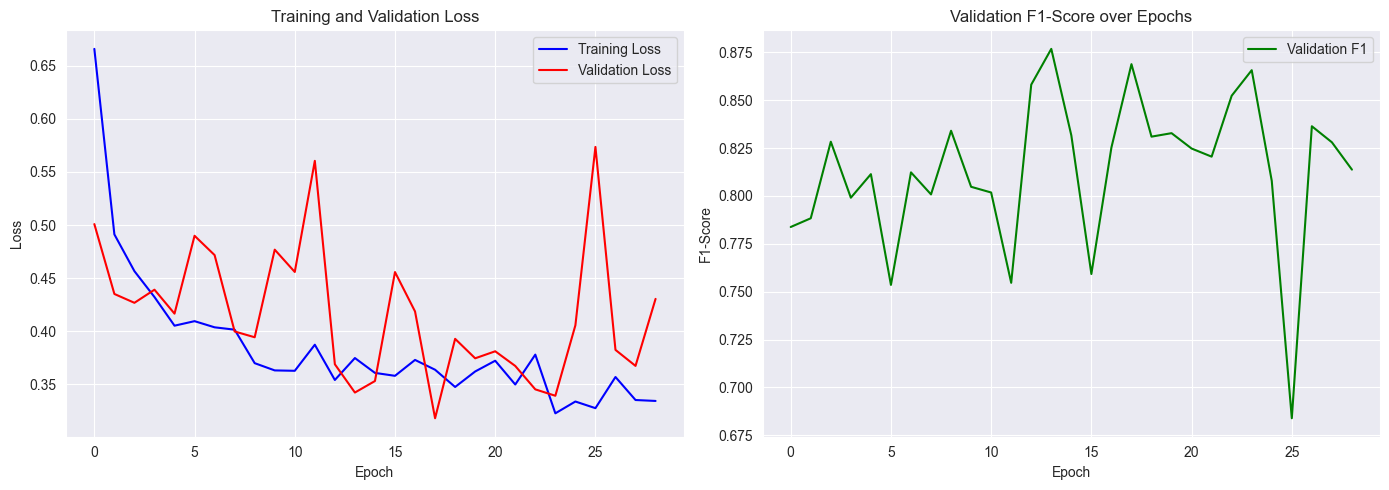

 نمودارها ذخیره شدند


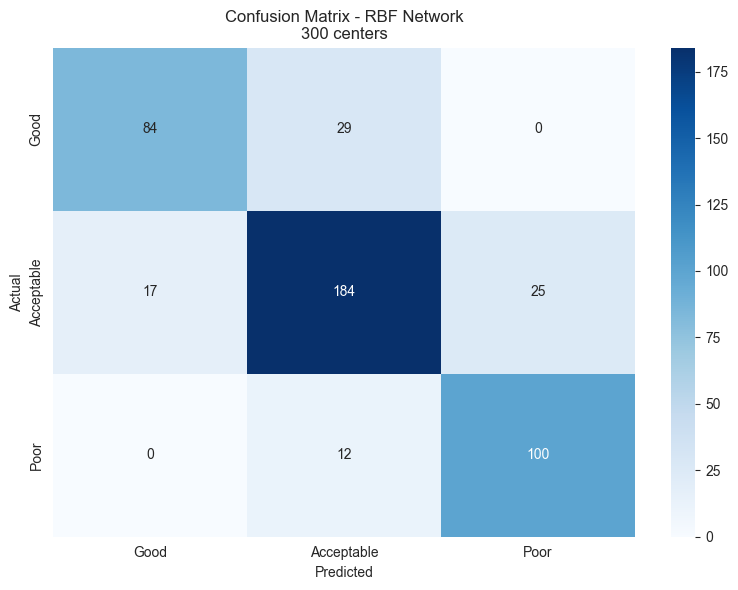

 ماتریس درهم‌ریختگی ذخیره شد


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# نمودار Loss
axes[0].plot(history['train_loss'], label='Training Loss', color='blue')
axes[0].plot(history['val_loss'], label='Validation Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# نمودار F1
axes[1].plot(history['val_f1'], label='Validation F1', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Validation F1-Score over Epochs')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('rbf_output/rbf_training_curves.png', dpi=150)
plt.show()
print(" نمودارها ذخیره شدند")

# ماتریس درهم‌ریختگی
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - RBF Network\n{best_n_centers} centers')
plt.tight_layout()
plt.savefig('rbf_output/rbf_confusion_matrix.png', dpi=150)
plt.show()
print(" ماتریس درهم‌ریختگی ذخیره شد")

In [45]:
torch.save(final_model.state_dict(), 'rbf_output/best_rbf_model.pth')
print(" مدل نهایی ذخیره شد: best_rbf_model.pth")

 مدل نهایی ذخیره شد: best_rbf_model.pth
